# 🌌 Mandelbrot: How Much Detail Can This Computer Handle?

The **Mandelbrot set** is a famous mathematical pattern called a **fractal**. Fractals contain intricate shapes that seem to keep revealing new detail as you zoom in. Similar kinds of repeating, self-similar patterns show up throughout nature—in things like ferns, tree branches, and snowflakes.

The Mandelbrot set is especially fun because a surprisingly simple rule creates an incredibly complicated image.

The rule is:

$$
z_{\text{next}} = z^2 + c
$$

Here, \(c\) represents the point in the image we're testing, and \(z\) is a value that starts at 0 and changes each time we repeat the calculation. What happens as we repeat the rule determines whether the point belongs to the Mandelbrot set-and ultimately the color that pixel gets.

**You do not need to understand the math behind this formula for this assignment.** The important part is what the computer has to do with it.

For every tiny point (pixel) in our image, the computer repeatedly applies that formula to determine what color the pixel should be. Then it does the same thing again for the next pixel. And the next. And the next.

A small image? No problem.

A huge, highly detailed image? Now we're asking the computer to perform **millions of calculations** while keeping a large amount of image data in memory.

**TL;DR:** Mandelbrot sets look cool. Making a really detailed one requires a massive amount of computation and memory. We're going to generate a highly detailed Mandelbrot set on two EC2 instances and compare what happens.

## 1. Set the resolution

A normal image might be 1000 × 1000 pixels.

We're going much bigger:

**6000 × 6000 = 36,000,000 points**

Python will try to keep information about all of those points in memory at the same time.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

SIZE = 6000
MAX_ITERATIONS = 40

print(f"Image size: {SIZE:,} × {SIZE:,}")
print(f"Points to calculate: {SIZE * SIZE:,}")


Image size: 5,000 × 5,000
Points to calculate: 25,000,000


## 2. Build the mathematical plane

Each pixel represents a complex number:

\[
c = x + yi
\]

We'll look at the interesting part of the Mandelbrot set.


In [3]:
x = np.linspace(-2.0, 1.0, SIZE, dtype=np.float32)
y = np.linspace(-1.5, 1.5, SIZE, dtype=np.float32)

# One complex number for every pixel
C = x[None, :] + 1j * y[:, None]
C = C.astype(np.complex64)

# z starts at zero everywhere
Z = np.zeros_like(C)

# Store the iteration where each point escapes
escape_time = np.zeros(C.shape, dtype=np.uint16)

print(f"Created {C.size:,} complex numbers.")


Created 25,000,000 complex numbers.


## 3. Run the Mandelbrot rule

For every point, repeatedly calculate:

```text
z = z² + c
```

If the magnitude becomes larger than 2, that point has escaped.

⚠️ **This is the memory-heavy step.**  
A micro EC2 instance may run out of RAM while trying to keep these giant arrays in memory.


In [4]:
for i in range(1, MAX_ITERATIONS + 1):

    # z = z² + c
    np.square(Z, out=Z)
    Z += C

    # |z|² = real² + imaginary²
    escaped = (Z.real * Z.real + Z.imag * Z.imag) > 4

    # Record the first iteration when each point escapes
    newly_escaped = escaped & (escape_time == 0)
    escape_time[newly_escaped] = i

    # Keep escaped values from growing forever
    Z[escaped] = 2 + 0j

    if i % 10 == 0:
        print(f"Finished iteration {i}/{MAX_ITERATIONS}")

print("Done!")


Finished iteration 10/40
Finished iteration 20/40
Finished iteration 30/40
Finished iteration 40/40
Done!


## 4. Reveal the fractal ✨

Dark areas stayed bounded longer.  
Bright areas escaped quickly.

If your computer made it this far, it successfully handled tens of millions of points at once.


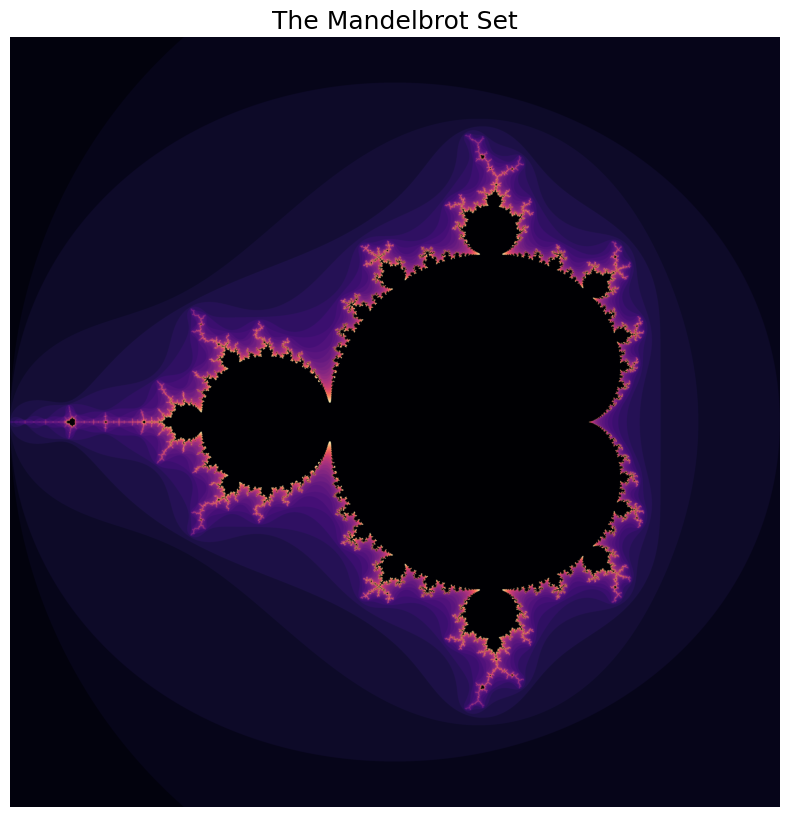

In [5]:
plt.figure(figsize=(10, 10))

plt.imshow(
    escape_time,
    extent=[-2, 1, -1.5, 1.5],
    origin="lower",
    cmap="magma"
)

plt.axis("off")
plt.title("The Mandelbrot Set", fontsize=18)
plt.show()


## Think About It

The math never changed.

We used the same rule on both machines:

$
z_{\text{next}} = z^2 + c
$

What changed was the **amount of data we asked the computer to hold at once**.